In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import xgboost as xgb
import shap

print('All libraries loaded')

All libraries loaded


In [2]:
DB_PATH = 'C:/Users/Saurabh yadav/Documents/SaaS Growth Intelligence Platform/database/saas_data.db'
conn = sqlite3.connect(DB_PATH)

accounts      = pd.read_sql('SELECT * FROM accounts', conn)
subscriptions = pd.read_sql('SELECT * FROM subscriptions', conn)
support       = pd.read_sql('SELECT * FROM support_tickets', conn)
feature_usage = pd.read_sql('SELECT * FROM feature_usage', conn)
conn.close()

print('Data loaded from database')
print('accounts shape:', accounts.shape)
print('subscriptions shape:', subscriptions.shape)

Data loaded from database
accounts shape: (500, 10)
subscriptions shape: (5000, 16)


In [3]:
accounts['signup_date'] = pd.to_datetime(accounts['signup_date'])

sub_features = subscriptions.groupby('account_id').agg(
    total_subscriptions   = ('subscription_id', 'count'),
    avg_mrr               = ('mrr_amount', 'mean'),
    total_mrr             = ('mrr_amount', 'sum'),
    upgrade_count         = ('upgrade_flag', 'sum'),
    downgrade_count       = ('downgrade_flag', 'sum'),
    avg_duration_days     = ('duration_days', 'mean'),
    trial_count           = ('is_trial', 'sum')
).reset_index()

support_features = support.groupby('account_id').agg(
    total_tickets         = ('ticket_id', 'count'),
    avg_satisfaction      = ('satisfaction_score', 'mean'),
    escalation_count      = ('escalation_flag', 'sum'),
    avg_resolution_hours  = ('resolution_time_hours', 'mean')
).reset_index()

usage_features = feature_usage.groupby('subscription_id').agg(
    total_usage_count     = ('usage_count', 'sum'),
    avg_usage_duration    = ('usage_duration_mins', 'mean'),
    total_errors          = ('error_count', 'sum'),
    unique_features_used  = ('feature_name', 'nunique')
).reset_index()

sub_with_usage = subscriptions[['subscription_id','account_id']].merge(
    usage_features, on='subscription_id', how='left')
usage_per_account = sub_with_usage.groupby('account_id').agg(
    total_usage_count    = ('total_usage_count', 'sum'),
    avg_usage_duration   = ('avg_usage_duration', 'mean'),
    total_errors         = ('total_errors', 'sum'),
    unique_features_used = ('unique_features_used', 'sum')
).reset_index()

df = accounts.merge(sub_features,     on='account_id', how='left')
df = df.merge(support_features,       on='account_id', how='left')
df = df.merge(usage_per_account,      on='account_id', how='left')
df = df.fillna(0)

print('Feature engineering done')
print('Dataset shape:', df.shape)
print('Churn rate:', round(df['churn_flag'].mean() * 100, 1), '%')

Feature engineering done
Dataset shape: (500, 25)
Churn rate: 22.0 %


In [4]:
le = LabelEncoder()
df['plan_tier_encoded']      = le.fit_transform(df['plan_tier'])
df['referral_source_encoded'] = le.fit_transform(df['referral_source'])
df['industry_encoded']        = le.fit_transform(df['industry'])

features = [
    'seats', 'plan_tier_encoded', 'referral_source_encoded', 'industry_encoded',
    'total_subscriptions', 'avg_mrr', 'total_mrr', 'upgrade_count',
    'downgrade_count', 'avg_duration_days', 'trial_count',
    'total_tickets', 'avg_satisfaction', 'escalation_count', 'avg_resolution_hours',
    'total_usage_count', 'avg_usage_duration', 'total_errors', 'unique_features_used'
]

X = df[features]
y = df['churn_flag'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print('Training set size:', X_train.shape)
print('Test set size:    ', X_test.shape)
print('Churn in test set:', y_test.sum(), 'out of', len(y_test))

Training set size: (400, 19)
Test set size:     (100, 19)
Churn in test set: 22 out of 100


In [6]:
model = xgb.XGBClassifier(
    n_estimators    = 200,
    max_depth       = 4,
    learning_rate   = 0.05,
    subsample       = 0.8,
    random_state    = 42,
    eval_metric     = 'logloss',
    use_label_encoder = False
)

model.fit(X_train, y_train)

y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_pred_prob)
print('ROC-AUC Score:', round(roc_auc, 4))
print()
print(classification_report(y_test, y_pred, target_names=['No Churn','Churned']))

ROC-AUC Score: 0.5577

              precision    recall  f1-score   support

    No Churn       0.78      0.94      0.85        78
     Churned       0.29      0.09      0.14        22

    accuracy                           0.75       100
   macro avg       0.54      0.51      0.50       100
weighted avg       0.68      0.75      0.70       100



C:\Users\Saurabh yadav\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:07:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


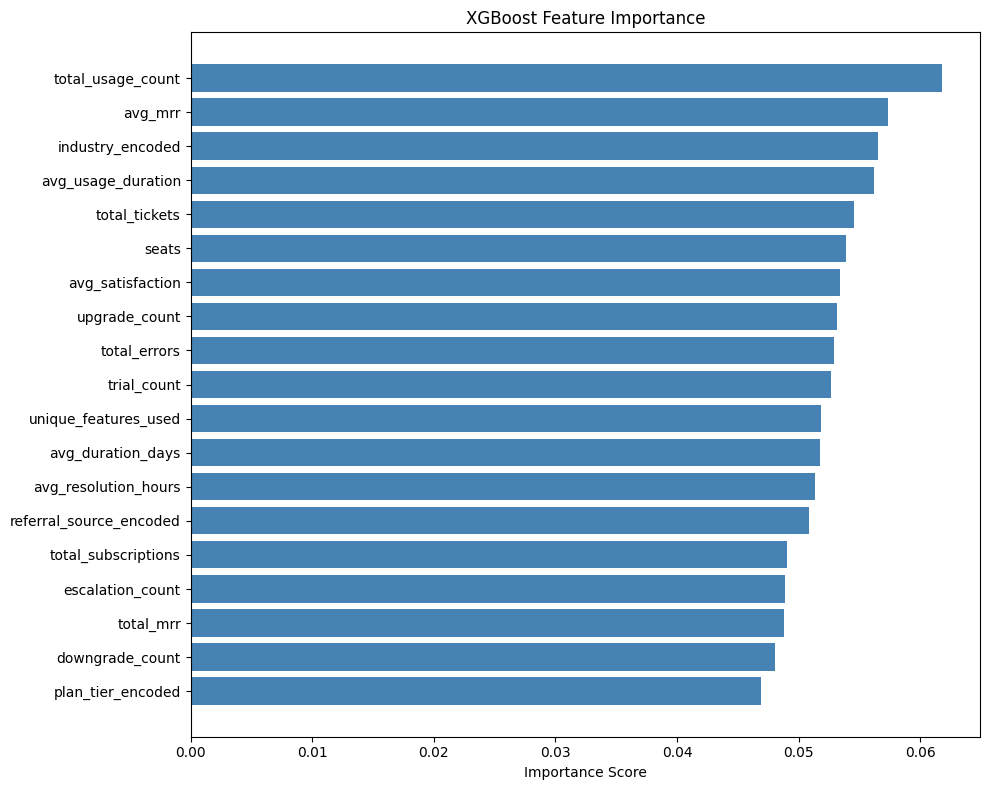

Top 5 churn drivers:
           feature  importance
 total_usage_count    0.061830
           avg_mrr    0.057375
  industry_encoded    0.056556
avg_usage_duration    0.056170
     total_tickets    0.054536


In [7]:
importance = pd.DataFrame({
    'feature':   features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(importance['feature'], importance['importance'], color='steelblue')
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()
print('Top 5 churn drivers:')
print(importance.tail(5)[['feature','importance']].iloc[::-1].to_string(index=False))

In [8]:
from sqlalchemy import create_engine

df['churn_probability'] = model.predict_proba(X)[:, 1].round(4)

def risk_label(prob):
    if prob >= 0.7:
        return 'High Risk'
    elif prob >= 0.4:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df['churn_risk_label'] = df['churn_probability'].apply(risk_label)

churn_scores = df[['account_id','churn_probability','churn_risk_label']]

engine = create_engine('sqlite:///C:/Users/Saurabh yadav/Documents/SaaS Growth Intelligence Platform/database/saas_data.db')
churn_scores.to_sql('churn_scores', engine, if_exists='replace', index=False)

print('Churn scores saved to database')
print(churn_scores['churn_risk_label'].value_counts())

Churn scores saved to database
churn_risk_label
Low Risk       400
High Risk       64
Medium Risk     36
Name: count, dtype: int64
